In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import zipfile
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
zip_path = "/content/drive/MyDrive/dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" extracted !")

 extracted !


# how many files are there?

In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root, "->", len(files))

/content/dataset -> 0
/content/dataset/dataset -> 1
/content/dataset/dataset/val -> 1
/content/dataset/dataset/val/no -> 2500
/content/dataset/dataset/val/sphere -> 2500
/content/dataset/dataset/val/vort -> 2500
/content/dataset/dataset/train -> 1
/content/dataset/dataset/train/no -> 10000
/content/dataset/dataset/train/sphere -> 10000
/content/dataset/dataset/train/vort -> 10000
/content/dataset/__MACOSX -> 0
/content/dataset/__MACOSX/dataset -> 1
/content/dataset/__MACOSX/dataset/val -> 1
/content/dataset/__MACOSX/dataset/train -> 1


# imports!

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import seaborn as sns
from tqdm import tqdm

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("Using device:", device)

Using device: cuda


# dataset class for loading .npy images and labels

In [ ]:
class DatasetNPY(Dataset):

    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):

        img = np.load(self.file_paths[idx])

        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32)

        # add channel if missing
        if img.ndim == 2:
            img = img.unsqueeze(0)

        # convert 1 channel -> 3 channel for ResNet/EfficientNet
        #needs to happen BEFORE transforms are applied
        if img.shape[0] == 1:
            img = img.repeat(3,1,1)

        # apply transforms
        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx]).long()

        return img, label

In [ ]:
data_dir = "/content/dataset/dataset/train"

class_names = ['no','sphere','vort']

file_paths = []
labels = []

class_to_idx = {c:i for i,c in enumerate(class_names)}

for class_name in class_names:

    class_path = os.path.join(data_dir,class_name)

    npy_files = [f for f in os.listdir(class_path) if f.endswith(".npy")]

    for f in npy_files:

        file_paths.append(os.path.join(class_path,f))
        labels.append(class_to_idx[class_name])

print("Total samples:",len(file_paths))

Total samples: 30000


In [ ]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths,
    labels,
    test_size=0.1,
    stratify=labels,
    random_state=42
)

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

In [ ]:
train_dataset = DatasetNPY(train_paths,train_labels,train_transform)

val_dataset = DatasetNPY(val_paths,val_labels,val_transform)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 3, 224, 224])


# function for building architecture of the neural network depending on model name passed as arguement

In [ ]:
def build_model(model_name, num_classes):

    # RESNET50
    if model_name == "resnet50":

        model = models.resnet50(weights="IMAGENET1K_V1")

        for name, param in model.named_parameters():
            if "layer3" in name or "layer4" in name or "fc" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        num_features = model.fc.in_features

        model.fc = nn.Sequential(
            nn.Linear(num_features,512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),

            nn.Linear(512,256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256,num_classes)
        )

    # EFFICIENTNET
    elif model_name == "efficientnet":

        model = models.efficientnet_b0(weights="IMAGENET1K_V1")

        num_features = model.classifier[1].in_features

        model.classifier[1] = nn.Linear(num_features, num_classes)

    # DENSENET
    elif model_name == "densenet":

        model = models.densenet121(weights="IMAGENET1K_V1")

        num_features = model.classifier.in_features

        model.classifier = nn.Linear(num_features, num_classes)

    # MOBILENET
    elif model_name == "mobilenet":

        model = models.mobilenet_v3_large(weights="IMAGENET1K_V1")

        num_features = model.classifier[3].in_features

        model.classifier[3] = nn.Linear(num_features, num_classes)

    # CONVNEXT
    elif model_name == "convnext":

        model = models.convnext_tiny(weights="IMAGENET1K_V1")

        num_features = model.classifier[2].in_features

        model.classifier[2] = nn.Linear(num_features, num_classes)

    # VGG
    elif model_name == "vgg16":

        model = models.vgg16(weights="IMAGENET1K_V1")

        num_features = model.classifier[6].in_features

        model.classifier[6] = nn.Linear(num_features, num_classes)

    # VISION TRANSFORMER
    elif model_name == "vit":

        model = models.vit_b_16(weights="IMAGENET1K_V1")

        num_features = model.heads.head.in_features

        model.heads.head = nn.Linear(num_features, num_classes)

    else:
        raise ValueError("Unknown model")

    return model.to(device)

# optimizer function

three important objects used during training of a model:

criterion  -> loss function

optimizer  -> updates weights

scheduler  -> adjusts learning rate

In [ ]:
def build_optimizer(model):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.3,
        patience=2
    )

    return criterion,optimizer,scheduler

# train epoch function

In [ ]:
def train_epoch(model,loader,criterion,optimizer):

    model.train()

    running_loss=0
    correct=0
    total=0

    for images,labels in tqdm(loader):

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

        _,predicted=outputs.max(1)

        total+=labels.size(0)

        correct+=predicted.eq(labels).sum().item()

    acc=correct/total

    return running_loss/len(loader),acc

# validation function

In [ ]:
def validate(model,loader,criterion):

    model.eval()

    running_loss=0
    correct=0
    total=0

    probs=[]
    labels_all=[]
    preds=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)
            labels=labels.to(device)

            outputs=model(images)

            loss=criterion(outputs,labels)

            running_loss+=loss.item()

            prob=torch.softmax(outputs,dim=1)

            pred=torch.argmax(prob,1)

            total+=labels.size(0)
            correct+=pred.eq(labels).sum().item()

            probs.extend(prob.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            preds.extend(pred.cpu().numpy())

    acc=correct/total

    return running_loss/len(loader),acc,probs,labels_all,preds

# train model function

In [ ]:
def train_model(model_name):

    model=build_model(model_name,3)

    criterion,optimizer,scheduler=build_optimizer(model)

    num_epochs=15

    history={
        "train_loss":[],
        "train_acc":[],
        "val_loss":[],
        "val_acc":[]
    }

    best_val=0

    for epoch in range(num_epochs):

        print("\nEpoch",epoch+1)

        train_loss,train_acc=train_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss,val_acc,probs,labels,preds=validate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print("Train Loss:",train_loss,"Train Acc:",train_acc)
        print("Val Loss:",val_loss,"Val Acc:",val_acc)

        if val_acc>best_val:

            best_val=val_acc

            torch.save({
                'model_state_dict':model.state_dict()
            },"best_model.pth")

    return model,history

# functions to plot metrics like accuracy, loss, confusion matrix, roc

In [ ]:
def plot_history(history):

    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    plt.plot(history['train_loss'])
    plt.plot(history['val_loss'])
    plt.title("Loss")

    plt.subplot(1,2,2)
    plt.plot(history['train_acc'])
    plt.plot(history['val_acc'])
    plt.title("Accuracy")

    plt.show()

In [ ]:
def plot_roc(labels,probs):

    labels_bin=label_binarize(labels,classes=[0,1,2])

    plt.figure(figsize=(8,6))

    for i in range(3):

        fpr,tpr,_=roc_curve(labels_bin[:,i],[p[i] for p in probs])

        roc_auc=auc(fpr,tpr)

        plt.plot(fpr,tpr,label=f"{class_names[i]} AUC={roc_auc:.3f}")

    plt.legend()
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()

In [ ]:
def plot_confusion(labels,preds):

    cm=confusion_matrix(labels,preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.show()

# ResNet50 model training and visualizing metrics


| Metric | Value |
|------|------|
| Model | ResNet50 (ImageNet pretrained) |
| Epochs | 15 |
| Batch Size | 32 |
| Optimizer | Adam |
| Learning Rate | 1e-4 |
| Scheduler | ReduceLROnPlateau |
| Final Train Accuracy | 79.89% |
| Final Validation Accuracy | 80.40% |
| Best Validation Accuracy | **81.03%** (Epoch 13) |
| Final Train Loss | 0.496 |
| Final Validation Loss | 0.462 |
| AUC (no) | 0.960 |
| AUC (sphere) | 0.911 |
| AUC (vort) | 0.952 |
| Macro AUC | **0.941** |

### Training Summary
- Training accuracy improved from **37.6% to 79.9%**
- Validation accuracy improved from **42.6% to 80.4%**
- Best validation performance occurred at **Epoch 13**
- Model shows strong discrimination ability with **Macro AUC ≈ 0.94**

### ROC Curve
Train and validation ROC curves show strong separation between classes with AUC values above **0.9** for all classes.

In [ ]:
resnet50_model,resnet50_history=train_model("resnet50")


Epoch 1


100%|██████████| 844/844 [03:27<00:00,  4.06it/s]


Train Loss: 1.1449870220010314 Train Acc: 0.37577777777777777
Val Loss: 1.0944317046632157 Val Acc: 0.4256666666666667

Epoch 2


100%|██████████| 844/844 [03:23<00:00,  4.15it/s]


Train Loss: 0.9994041550357194 Train Acc: 0.49577777777777776
Val Loss: 0.9968990068486396 Val Acc: 0.5266666666666666

Epoch 3


...

Train Loss: 0.5358070645710868 Train Acc: 0.7779259259259259
Val Loss: 0.46738934184008457 Val Acc: 0.8103333333333333

Epoch 14


100%|██████████| 844/844 [03:39<00:00,  3.85it/s]


Train Loss: 0.5153137353818281 Train Acc: 0.7876666666666666
Val Loss: 0.48112088632076344 Val Acc: 0.8093333333333333

Epoch 15


100%|██████████| 844/844 [03:24<00:00,  4.13it/s]


Train Loss: 0.49578055578738595 Train Acc: 0.7989259259259259
Val Loss: 0.46242492852058814 Val Acc: 0.804


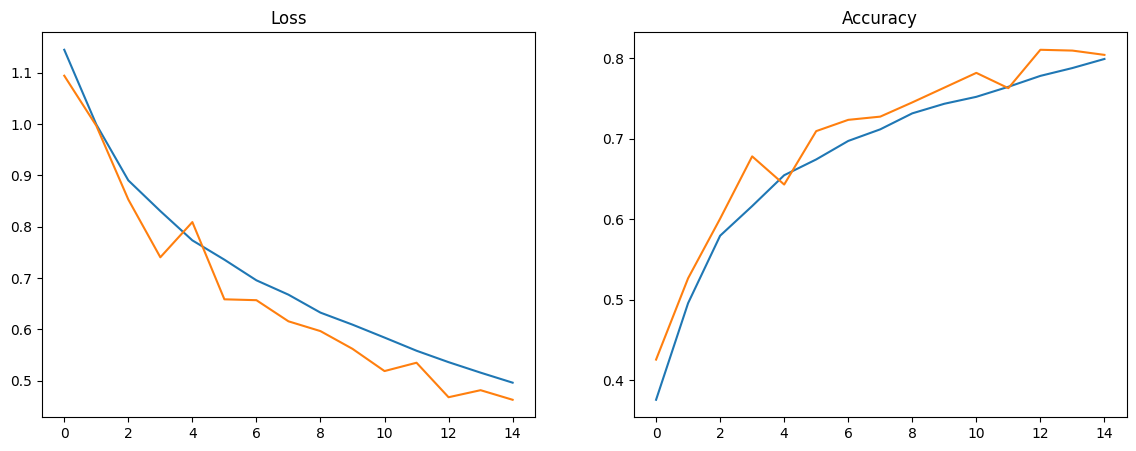

In [ ]:
plot_history(resnet50_history)

In [ ]:
val_loss,val_acc,probs,labels,preds=validate(
    resnet50_model,
    val_loader,
    nn.CrossEntropyLoss()
)

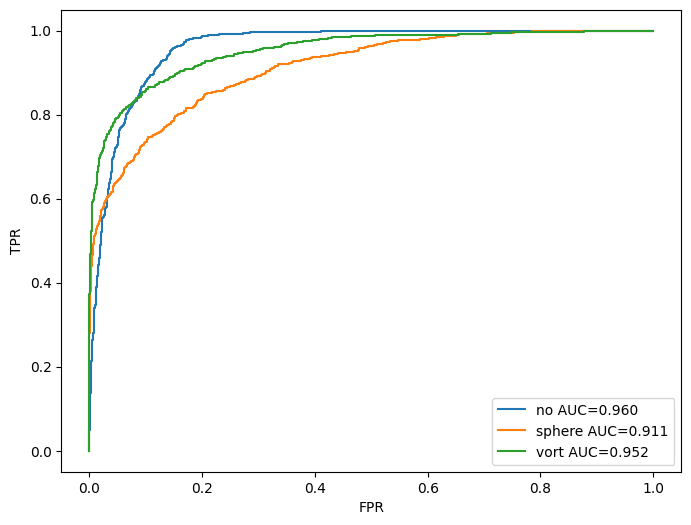

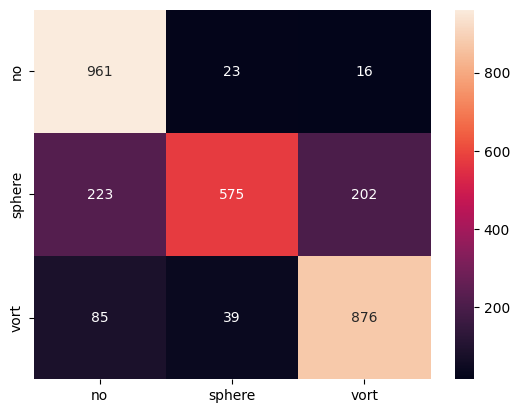

In [ ]:
plot_roc(labels,probs)

plot_confusion(labels,preds)

In [ ]:
_, _, train_probs, train_labels, _ = validate(
    resnet50_model,
    train_loader,
    nn.CrossEntropyLoss()
)

In [ ]:
def plot_train_val_roc(train_labels, train_probs, val_labels, val_probs, class_names):
    labels_bin_train = label_binarize(train_labels, classes=[0, 1, 2])
    labels_bin_val = label_binarize(val_labels, classes=[0, 1, 2])

    plt.figure(figsize=(10, 8))

    for i in range(len(class_names)):
        fpr_train, tpr_train, _ = roc_curve(labels_bin_train[:, i], [p[i] for p in train_probs])
        roc_auc_train = auc(fpr_train, tpr_train)
        plt.plot(fpr_train, tpr_train, label=f'Train {class_names[i]} AUC = {roc_auc_train:.3f}', linestyle='--')

        fpr_val, tpr_val, _ = roc_curve(labels_bin_val[:, i], [p[i] for p in val_probs])
        roc_auc_val = auc(fpr_val, tpr_val)
        plt.plot(fpr_val, tpr_val, label=f'Val {class_names[i]} AUC = {roc_auc_val:.3f}', linestyle='-')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance level')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve - Train vs Validation')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

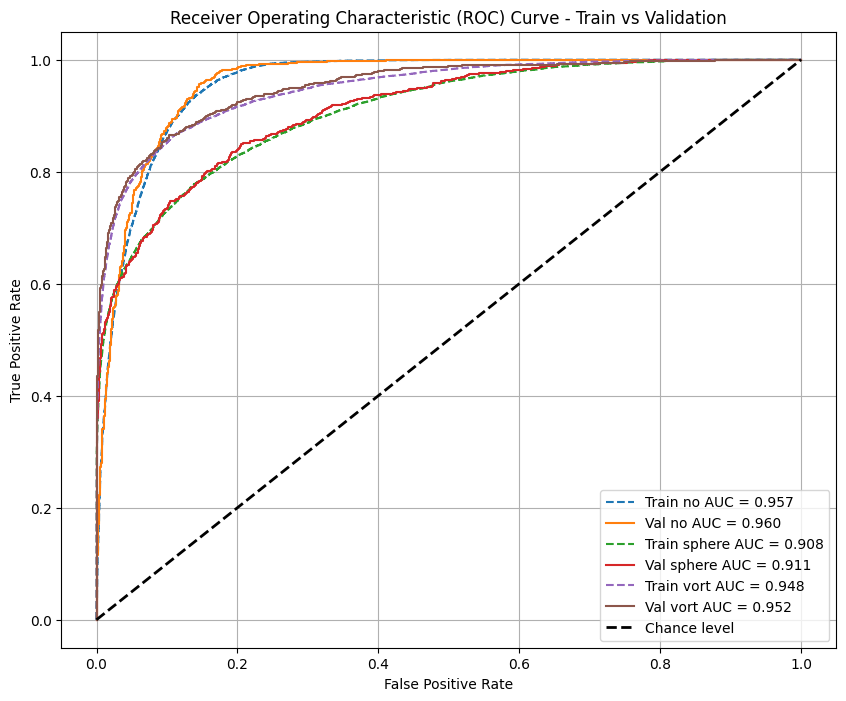

In [ ]:
plot_train_val_roc(train_labels, train_probs, labels, probs, class_names)

# EfficientNet model training and visualizing metrics


| Metric | Value |
|------|------|
| Model | EfficientNet-B0 (ImageNet pretrained) |
| Epochs | 15 |
| Batch Size | 32 |
| Optimizer | Adam |
| Learning Rate | 1e-4 |
| Scheduler | ReduceLROnPlateau |
| Final Train Accuracy | 91.74% |
| Final Validation Accuracy | **93.13%** |
| Best Validation Accuracy | **93.13%** (Epoch 15) |
| Final Train Loss | 0.221 |
| Final Validation Loss | 0.189 |
| AUC (no) | 0.9915 |
| AUC (sphere) | 0.9815 |
| AUC (vort) | 0.9920 |
| Macro AUC | **0.9883** |

### Classification Metrics (Validation)

| Class | Precision | Recall | F1-score |
|------|------|------|------|
| no | 0.90 | 0.99 | 0.94 |
| sphere | 0.96 | 0.85 | 0.91 |
| vort | 0.94 | 0.95 | 0.94 |

### Training Summary
- Training accuracy improved from **42.7% to 91.7%**
- Validation accuracy improved from **57.8% to 93.1%**
- Best validation performance achieved at **Epoch 15**
- Model shows **excellent class separability with Macro AUC ≈ 0.988**

### ROC Curve
Validation ROC curves show near-perfect separation for all classes, with AUC values **above 0.98**.

In [ ]:
efficientnet_model,efficientnet_history=train_model("efficientnet")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.7MB/s]



Epoch 1


100%|██████████| 844/844 [02:51<00:00,  4.93it/s]


Train Loss: 1.043022832458053 Train Acc: 0.4265185185185185
Val Loss: 0.8740319793528699 Val Acc: 0.578

Epoch 2


...

Train Loss: 0.24409095740378325 Train Acc: 0.9077037037037037
Val Loss: 0.19555943003518783 Val Acc: 0.9263333333333333

Epoch 14


100%|██████████| 844/844 [02:51<00:00,  4.91it/s]


Train Loss: 0.23343646821623307 Train Acc: 0.9115185185185185
Val Loss: 0.2033853371171875 Val Acc: 0.9266666666666666

Epoch 15


100%|██████████| 844/844 [02:54<00:00,  4.83it/s]


Train Loss: 0.22095036894188955 Train Acc: 0.9174444444444444
Val Loss: 0.18898097905231284 Val Acc: 0.9313333333333333


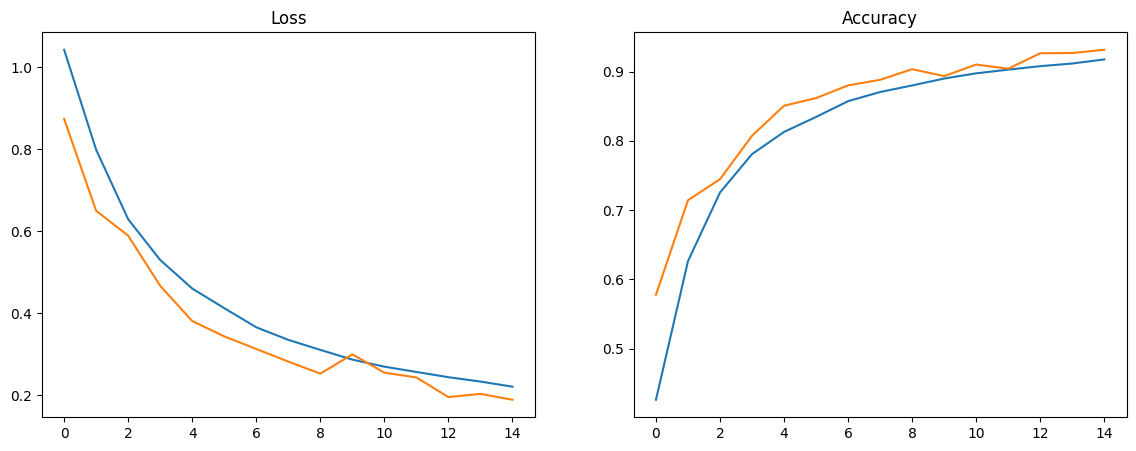

In [ ]:
plot_history(efficientnet_history)

In [ ]:
val_loss,val_acc,probs,labels,preds=validate(
    efficientnet_model,
    val_loader,
    nn.CrossEntropyLoss()
)

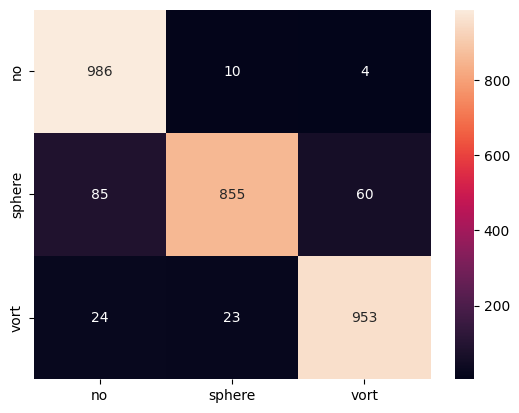

In [ ]:
plot_confusion(labels,preds)

In [ ]:
_, _, train_probs, train_labels, _ = validate(
    efficientnet_model,
    train_loader,
    nn.CrossEntropyLoss()
)

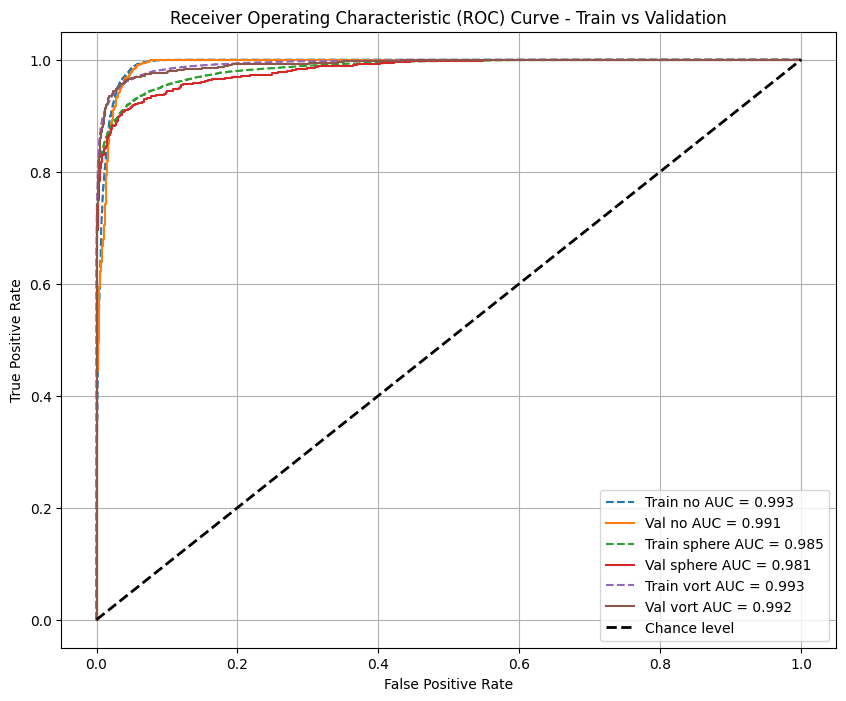

In [ ]:
plot_train_val_roc(train_labels, train_probs, labels, probs, class_names)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print('--- EfficientNet Classification Report (Validation Set) ---')
print(classification_report(labels, preds, target_names=class_names))
print(f'Overall Validation Accuracy: {val_acc:.4f}')

--- EfficientNet Classification Report (Validation Set) ---
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      1000
      sphere       0.96      0.85      0.91      1000
        vort       0.94      0.95      0.94      1000

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000

Overall Validation Accuracy: 0.9313


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

labels_binarized = label_binarize(labels, classes=[0, 1, 2])

print(' EfficientNet AUC Scores (Validation Set) ')

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], [p[i] for p in probs])
    roc_auc = auc(fpr, tpr)
    print(f'AUC for class {class_name} ({i}): {roc_auc:.4f}')

overall_auc_macro = roc_auc_score(labels_binarized, probs, multi_class='ovr', average='macro')
print(f'Overall AUC (Macro Average): {overall_auc_macro:.4f}')


 EfficientNet AUC Scores (Validation Set) 
AUC for class no (0): 0.9915
AUC for class sphere (1): 0.9815
AUC for class vort (2): 0.9920
Overall AUC (Macro Average): 0.9883


column 1 : for class 0 (no)

column 2 : for class 1 ( sphere)

column 3 : for class 2 (vort)

In [ ]:
labels_binarized

array([[0, 0, 1],
       [0, 0, 1],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [1, 0, 0],
       [0, 0, 1]])

# DenseNet model training and visualizing metrics

| Metric | Value |
|------|------|
| Model | DenseNet121 (ImageNet pretrained) |
| Epochs | 15 |
| Batch Size | 32 |
| Optimizer | Adam |
| Learning Rate | 1e-4 |
| Scheduler | ReduceLROnPlateau |
| Final Train Accuracy | **96.30%** |
| Final Validation Accuracy | **96.27%** |
| Best Validation Accuracy | **96.27%** (Epoch 15) |
| Final Train Loss | 0.106 |
| Final Validation Loss | 0.111 |
| AUC (no) | 0.9957 |
| AUC (sphere) | 0.9931 |
| AUC (vort) | 0.9980 |
| Macro AUC | **0.9956** |


## Classification Metrics (Validation)

| Class | Precision | Recall | F1-score |
|------|------|------|------|
| no | 0.93 | 0.99 | 0.96 |
| sphere | 0.99 | 0.93 | 0.95 |
| vort | 0.98 | 0.97 | 0.97 |


## Training Summary

- Training accuracy improved from **63.4% to 96.3%**
- Validation accuracy improved from **84.8% to 96.27%**
- Best validation performance achieved at **Epoch 15**
- Model shows **excellent class separability with Macro AUC ≈ 0.996**
- Training and validation curves indicate **minimal overfitting**


## ROC Curve

Validation ROC curves show **near-perfect separation for all classes**, with AUC values above **0.99** for all three lensing categories (`no`, `sphere`, `vort`).

The curves lie close to the **top-left corner**, indicating high true positive rates with very low false positive rates.

---

- **DenseNet121 performs strongly on the lensing classification task**, achieving over **96% validation accuracy**.
- The model demonstrates **balanced performance across all three classes**.
- The **`vort` class achieves the highest F1-score (0.97)**, indicating robust detection of vortex-like lensing patterns.
- Slightly lower recall for **sphere** suggests some sphere samples are misclassified as other classes.

In [ ]:
densenet_model,densenet_history=train_model("densenet")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 96.0MB/s]



Epoch 1


100%|██████████| 844/844 [05:16<00:00,  2.67it/s]


Train Loss: 0.7558715610778163 Train Acc: 0.6341851851851852
Val Loss: 0.3974921519451953 Val Acc: 0.848

Epoch 2


...

Train Loss: 0.15388817564248863 Train Acc: 0.945
Val Loss: 0.16094672870128712 Val Acc: 0.939

Epoch 14


100%|██████████| 844/844 [04:59<00:00,  2.82it/s]


Train Loss: 0.1508721432657427 Train Acc: 0.9481851851851851
Val Loss: 0.15584330871562532 Val Acc: 0.947

Epoch 15


100%|██████████| 844/844 [04:59<00:00,  2.82it/s]


Train Loss: 0.10647533158661347 Train Acc: 0.963
Val Loss: 0.11116727339500125 Val Acc: 0.9626666666666667


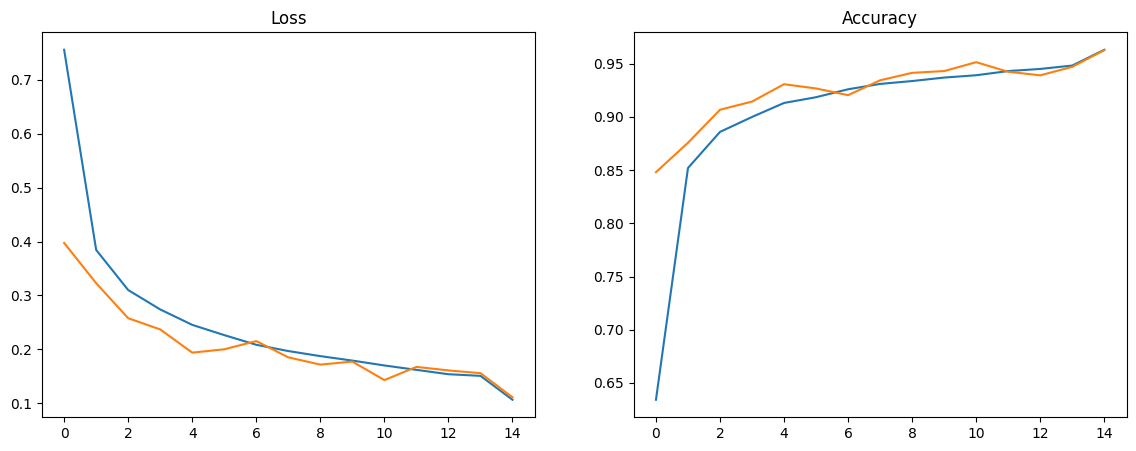

In [ ]:
plot_history(densenet_history)

In [ ]:
val_loss,val_acc,probs,labels,preds=validate(
    densenet_model,
    val_loader,
    nn.CrossEntropyLoss()
)

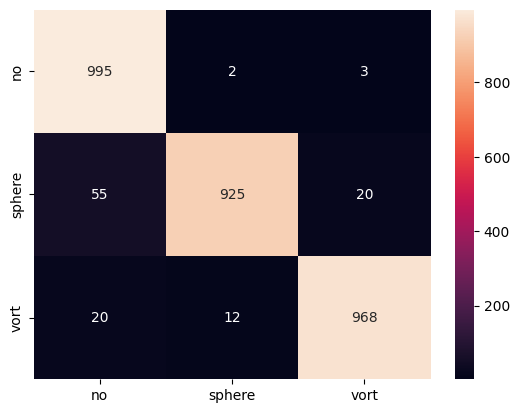

In [ ]:
plot_confusion(labels,preds)

In [ ]:
_, _, train_probs, train_labels, _ = validate(
    densenet_model,
    train_loader,
    nn.CrossEntropyLoss()
)

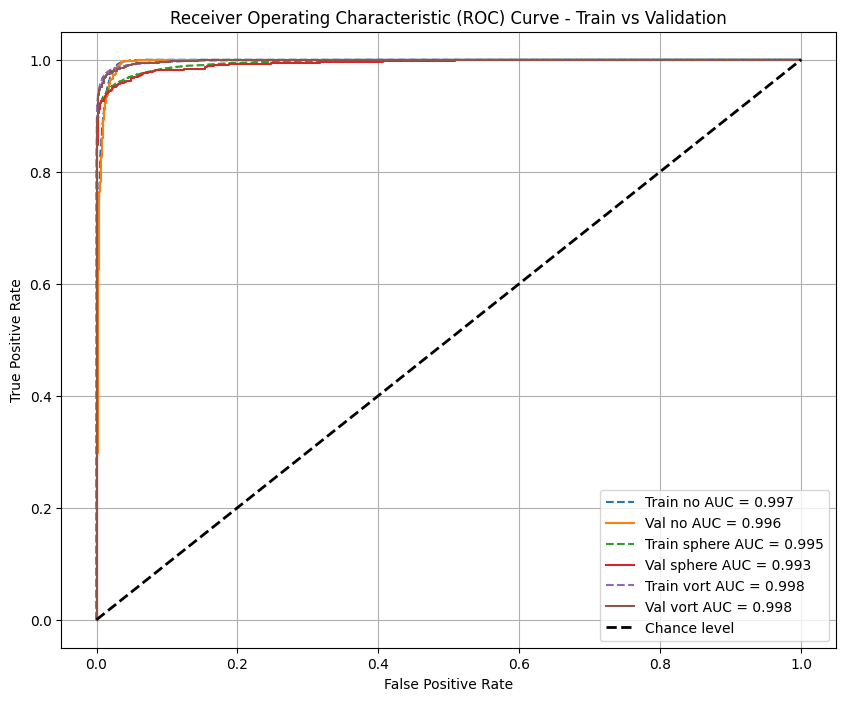

In [ ]:
plot_train_val_roc(train_labels, train_probs, labels, probs, class_names)

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(' DenseNet Classification Report (Validation Set) ')
print(classification_report(labels, preds, target_names=class_names))
print(f'Overall Validation Accuracy: {val_acc:.4f}')

 DenseNet Classification Report (Validation Set) 
              precision    recall  f1-score   support

          no       0.93      0.99      0.96      1000
      sphere       0.99      0.93      0.95      1000
        vort       0.98      0.97      0.97      1000

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000

Overall Validation Accuracy: 0.9627


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report

labels_binarized = label_binarize(labels, classes=[0, 1, 2])

print(' DenseNet AUC Scores (Validation Set) ')

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], [p[i] for p in probs])
    roc_auc = auc(fpr, tpr)
    print(f'AUC for class {class_name} ({i}): {roc_auc:.4f}')

overall_auc_macro = roc_auc_score(labels_binarized, probs, multi_class='ovr', average='macro')
print(f'Overall AUC (Macro Average): {overall_auc_macro:.4f}')


 DenseNet AUC Scores (Validation Set) 
AUC for class no (0): 0.9957
AUC for class sphere (1): 0.9931
AUC for class vort (2): 0.9980
Overall AUC (Macro Average): 0.9956


# MobileNet model training and visualizing metrics

| Metric | Value |
|------|------|
| Model | MobileNetV3-Large (ImageNet pretrained) |
| Epochs | 15 |
| Batch Size | 32 |
| Optimizer | Adam |
| Learning Rate | 1e-4 |
| Scheduler | ReduceLROnPlateau |
| Final Train Accuracy | **91.86%** |
| Final Validation Accuracy | **92.67%** |
| Best Validation Accuracy | **92.67%** (Epoch 15) |
| Final Train Loss | 0.216 |
| Final Validation Loss | 0.215 |
| AUC (no) | 0.9900 |
| AUC (sphere) | 0.9788 |
| AUC (vort) | 0.9902 |
| Macro AUC | **0.9863** |


## Classification Metrics (Validation)

| Class | Precision | Recall | F1-score |
|------|------|------|------|
| no | 0.93 | 0.96 | 0.94 |
| sphere | 0.95 | 0.87 | 0.91 |
| vort | 0.91 | 0.95 | 0.93 |


## Training Summary

- Training accuracy improved from **41.3% → 91.9%**
- Validation accuracy improved from **46.5% → 92.7%**
- Best validation performance achieved at **Epoch 15**
- Model achieved **Macro AUC ≈ 0.986**, indicating strong class separability


## ROC Curve

Validation ROC curves demonstrate **strong separation between the three lensing classes**, with AUC values close to **0.99** for most classes.


In [ ]:
mobilenet_model, mobilenet_history=train_model("mobilenet")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 63.5MB/s]



Epoch 1


100%|██████████| 844/844 [02:48<00:00,  5.01it/s]


Train Loss: 1.0624270588159561 Train Acc: 0.4126666666666667
Val Loss: 1.0194574106246868 Val Acc: 0.4653333333333333

Epoch 2


...

Train Loss: 0.23599681167055575 Train Acc: 0.9116666666666666
Val Loss: 0.38099573314824003 Val Acc: 0.8523333333333334

Epoch 14


100%|██████████| 844/844 [02:49<00:00,  4.97it/s]


Train Loss: 0.2242193682631257 Train Acc: 0.9136666666666666
Val Loss: 0.23803531021830884 Val Acc: 0.914

Epoch 15


100%|██████████| 844/844 [02:38<00:00,  5.32it/s]


Train Loss: 0.21613579339643507 Train Acc: 0.9186296296296297
Val Loss: 0.21461992508711966 Val Acc: 0.9266666666666666


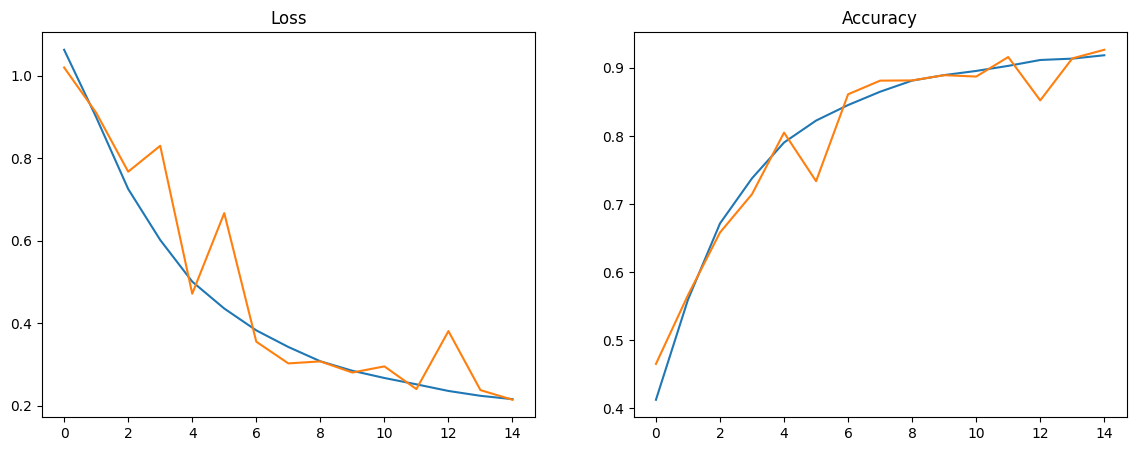

In [ ]:
plot_history(mobilenet_history)

In [ ]:
val_loss,val_acc,probs,labels,preds=validate(
    mobilenet_model,
    val_loader,
    nn.CrossEntropyLoss()
)

In [ ]:
probs[0]

array([2.3602981e-05, 4.4062486e-04, 9.9953580e-01], dtype=float32)

In [ ]:
preds[0]

np.int64(2)

In [ ]:
labels[0]

np.int64(2)

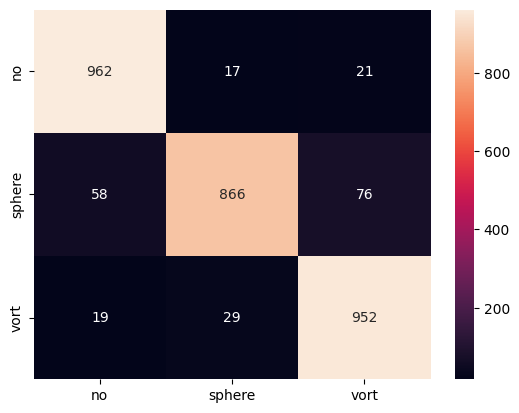

In [ ]:
plot_confusion(labels,preds)

In [ ]:
_, _, train_probs, train_labels, _ = validate(
    mobilenet_model,
    train_loader,
    nn.CrossEntropyLoss()
)

In [ ]:
train_probs[0], train_labels[0]

(array([2.7935127e-06, 9.0172130e-01, 9.8275900e-02], dtype=float32),
 np.int64(1))

In [ ]:
label_binarize(train_labels, classes=[0, 1, 2])

array([[0, 1, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [0, 1, 0],
       [0, 0, 1],
       [0, 0, 1]])

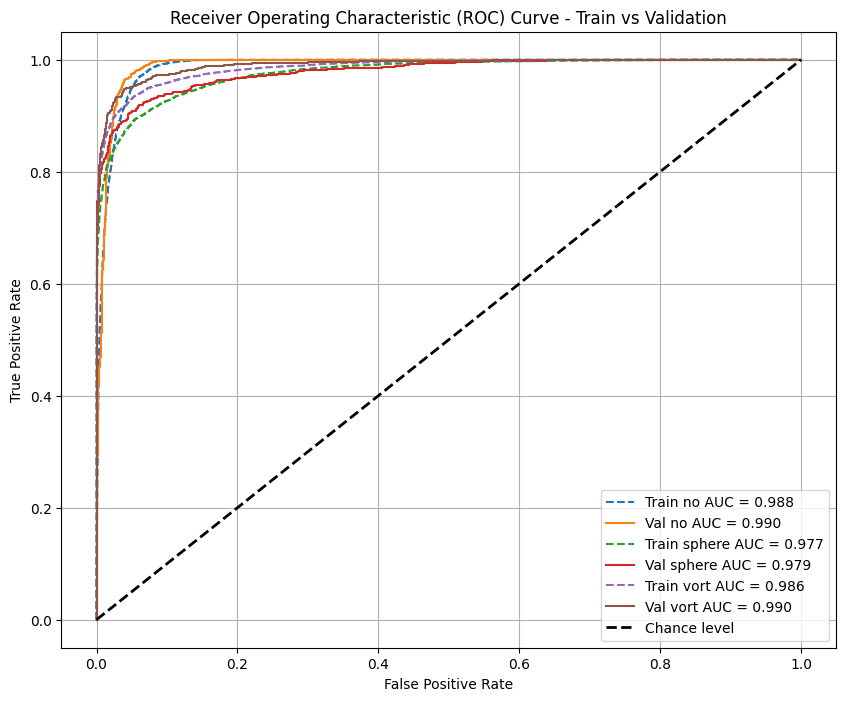

In [ ]:
plot_train_val_roc(train_labels, train_probs, labels, probs, class_names)

In [ ]:
print(' MobileNet Classification Report (Validation Set) ')
print(classification_report(labels, preds, target_names=class_names))
print(f'Overall Validation Accuracy: {val_acc:.4f}')

 MobileNet Classification Report (Validation Set) 
              precision    recall  f1-score   support

          no       0.93      0.96      0.94      1000
      sphere       0.95      0.87      0.91      1000
        vort       0.91      0.95      0.93      1000

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000

Overall Validation Accuracy: 0.9267


In [ ]:
labels_binarized = label_binarize(labels, classes=[0, 1, 2])

print(' MobileNet AUC Scores (Validation Set) ')

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], [p[i] for p in probs])
    roc_auc = auc(fpr, tpr)
    print(f'AUC for class {class_name} ({i}): {roc_auc:.4f}')

overall_auc_macro = roc_auc_score(labels_binarized, probs, multi_class='ovr', average='macro')
print(f'Overall AUC (Macro Average): {overall_auc_macro:.4f}')

 MobileNet AUC Scores (Validation Set) 
AUC for class no (0): 0.9900
AUC for class sphere (1): 0.9788
AUC for class vort (2): 0.9902
Overall AUC (Macro Average): 0.9863
